## Compare Two Model Fits

Quick sanity check: load two fitted models and plot their confusion matrix to see how similar the discovered syllables are.

<Figure size 600x500 with 0 Axes>

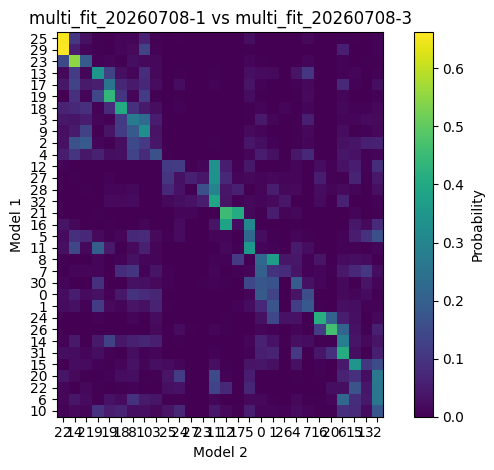

In [16]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
from pathlib import Path

WORKDIR = Path.cwd().parent
project_dir = WORKDIR / "results" / "ElevatedMazeFood"

# pick two fitted models
model_name_1 = "multi_fit_20260708-1"
model_name_2 = "multi_fit_20260708-3"

results_1 = kpms.load_results(str(project_dir), model_name_1)
results_2 = kpms.load_results(str(project_dir), model_name_2)

plt.figure(figsize=(6, 5))
kpms.plot_confusion_matrix(results_1, results_2)
plt.title(f"{model_name_1} vs {model_name_2}")
plt.show()

## Compare One Reference Model Against All Others

Use one model as a reference and iterate over the rest of the ensemble.

Tip: if this is too many figures, reduce `num_models` or sample a subset of indices.

Reference model: multi_fit_20260708-13


<Figure size 600x500 with 0 Axes>

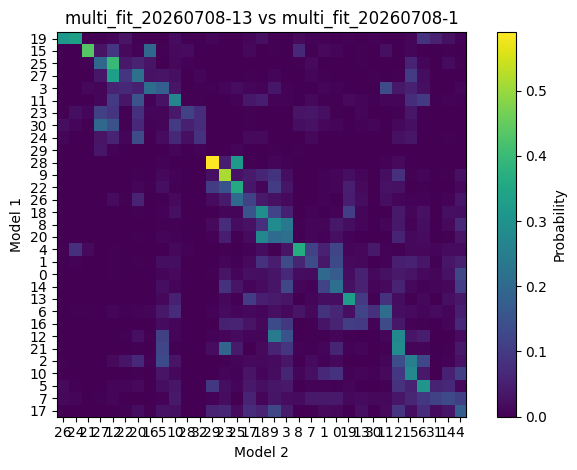

<Figure size 600x500 with 0 Axes>

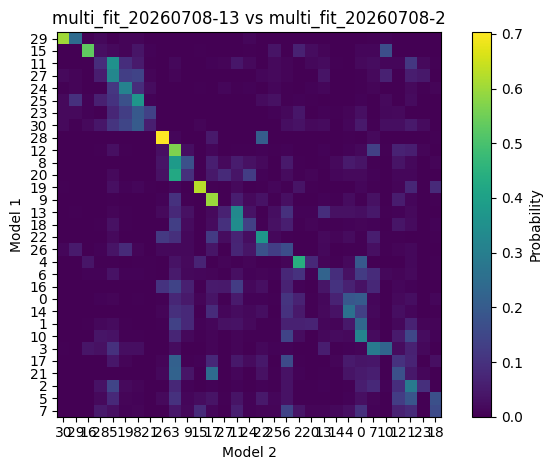

<Figure size 600x500 with 0 Axes>

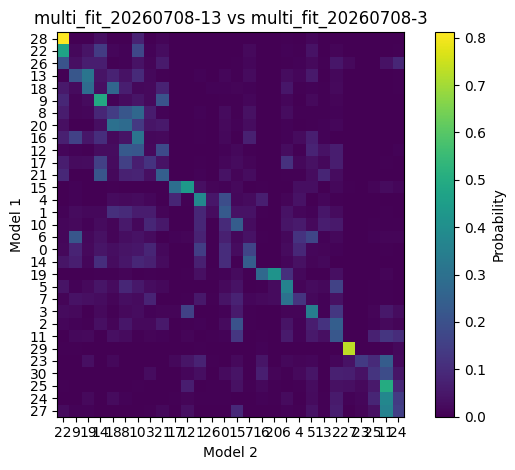

<Figure size 600x500 with 0 Axes>

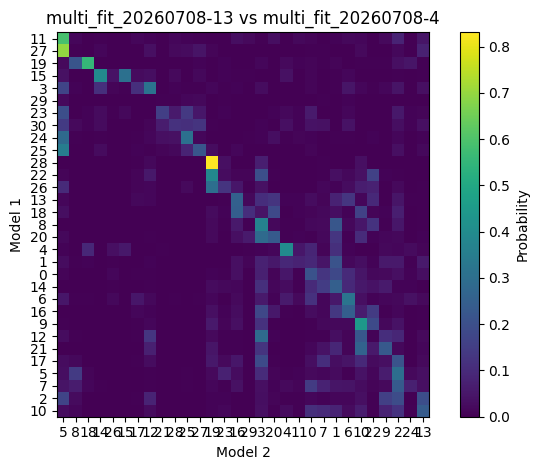

<Figure size 600x500 with 0 Axes>

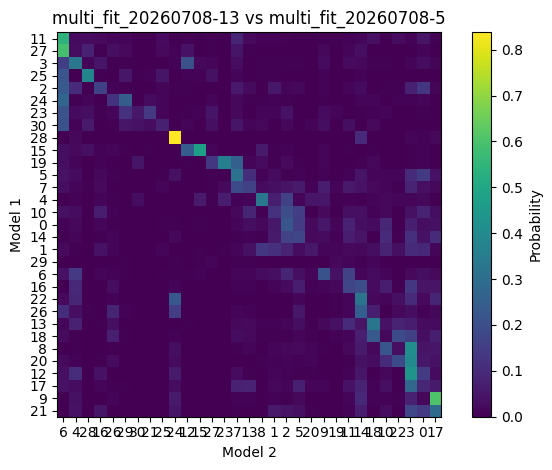

<Figure size 600x500 with 0 Axes>

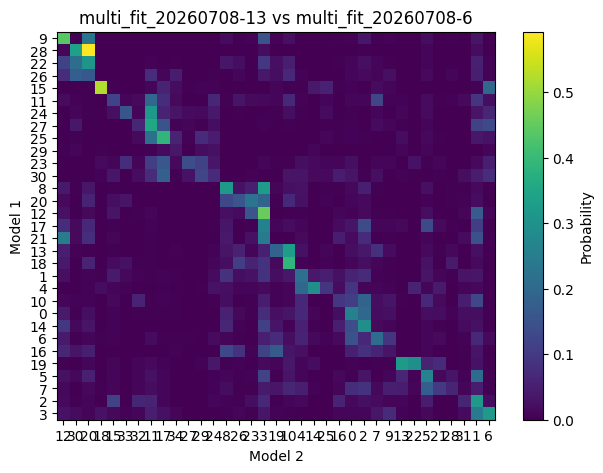

<Figure size 600x500 with 0 Axes>

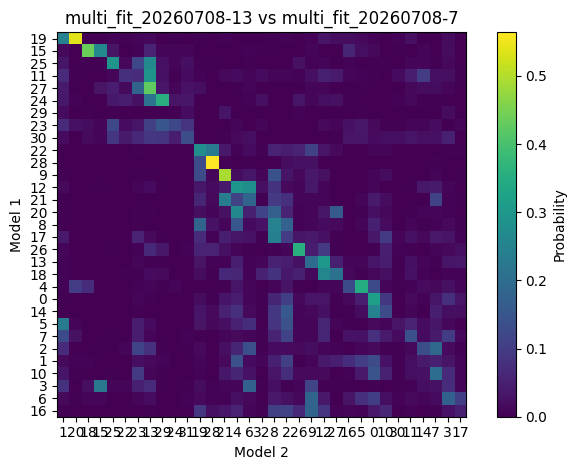

<Figure size 600x500 with 0 Axes>

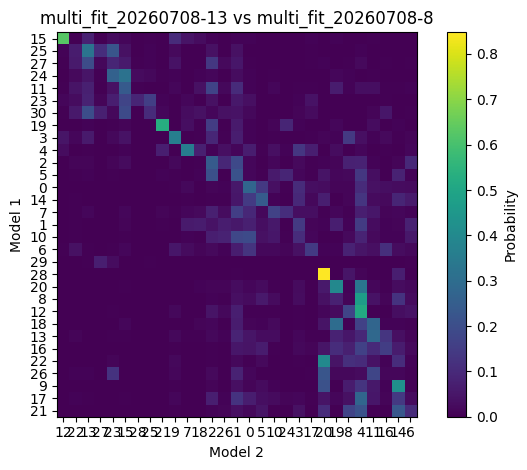

<Figure size 600x500 with 0 Axes>

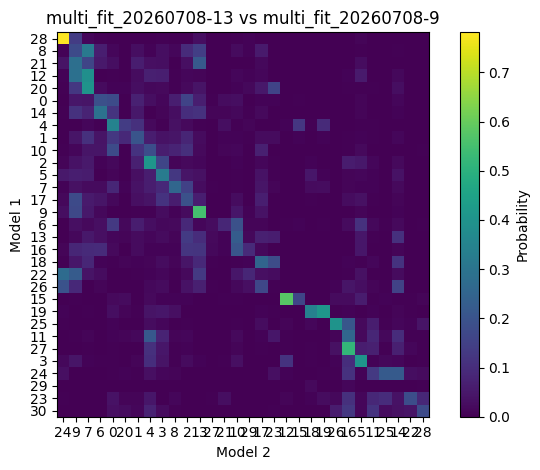

<Figure size 600x500 with 0 Axes>

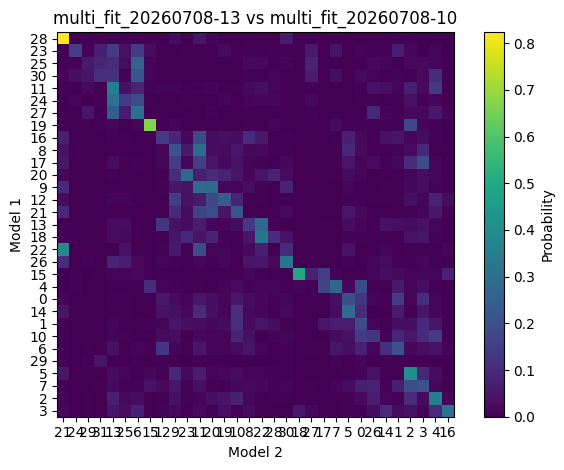

<Figure size 600x500 with 0 Axes>

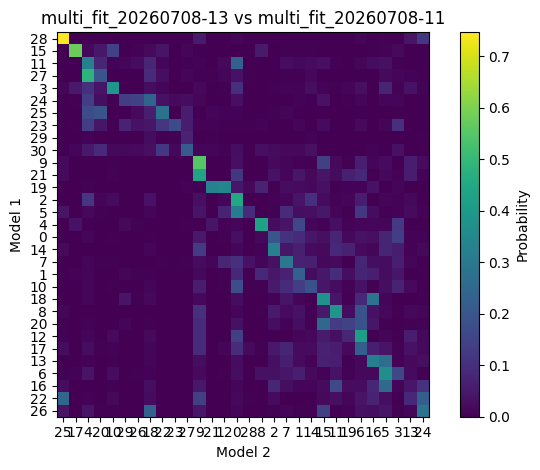

<Figure size 600x500 with 0 Axes>

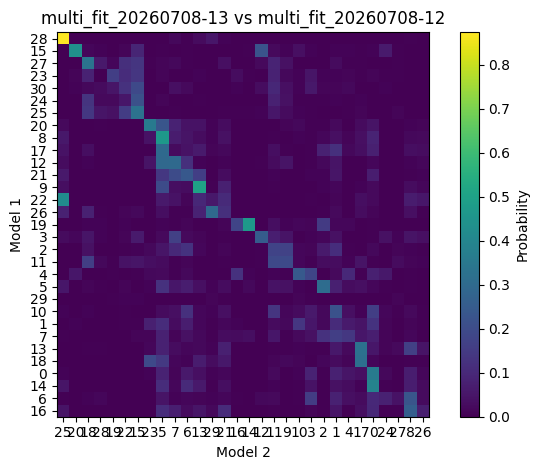

<Figure size 600x500 with 0 Axes>

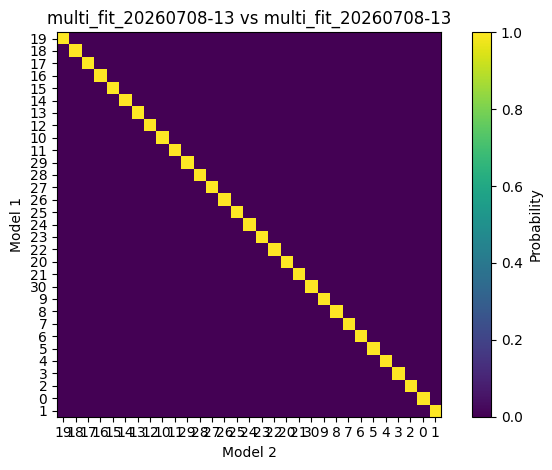

<Figure size 600x500 with 0 Axes>

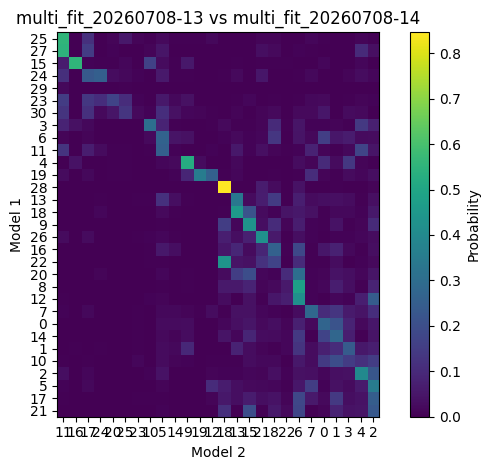

<Figure size 600x500 with 0 Axes>

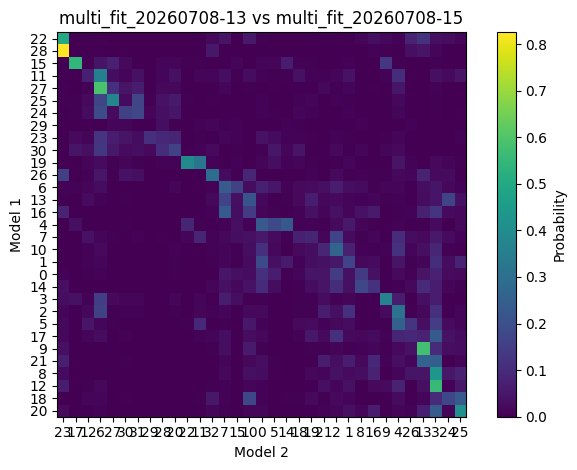

<Figure size 600x500 with 0 Axes>

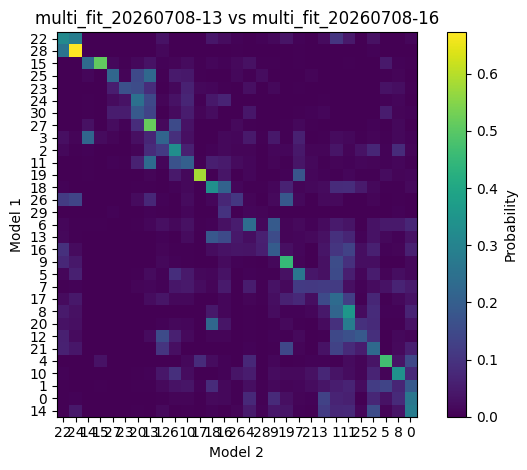

<Figure size 600x500 with 0 Axes>

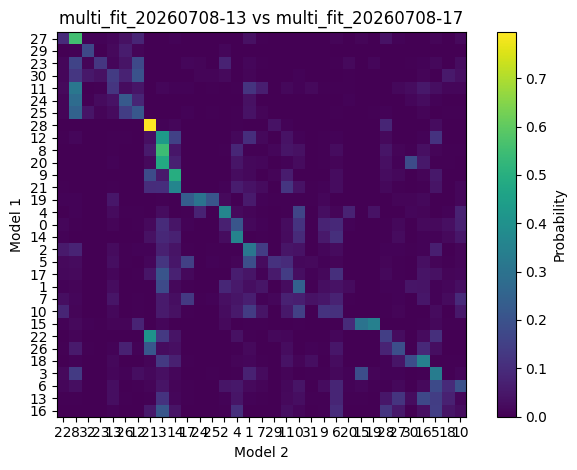

<Figure size 600x500 with 0 Axes>

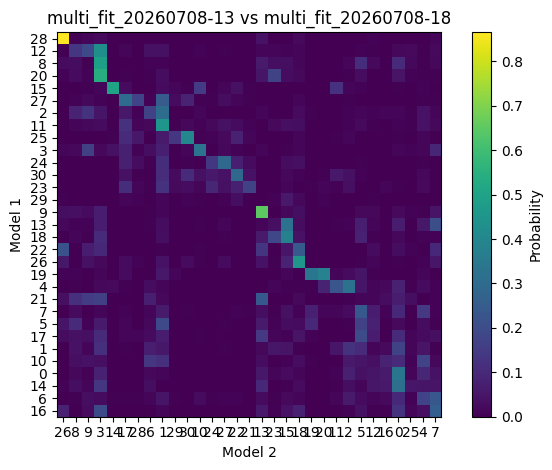

<Figure size 600x500 with 0 Axes>

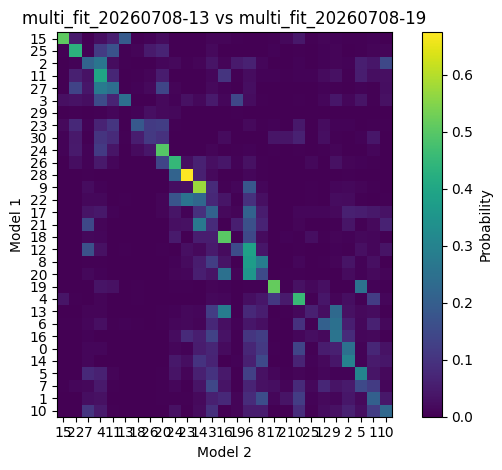

In [17]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt

prefix = "multi_fit_20260708"
num_models = 20

ref = f"{prefix}-13"
print(f"Reference model: {ref}")
results_ref = kpms.load_results(str(project_dir), ref)

for i in range(1, num_models):
    other = f"{prefix}-{i}"
    results_other = kpms.load_results(str(project_dir), other)

    plt.figure(figsize=(6, 5))
    kpms.plot_confusion_matrix(results_ref, results_other)
    plt.title(f"{ref} vs {other}")
    plt.tight_layout()
    plt.show()

## Select Best Model by EML

Compute expected marginal likelihood (EML) across model restarts, then choose the best-scoring model.

Make sure `model_names` matches the prefix and number of fitted runs on disk.

100%|███████████████████████████████████| 20/20 [02:45<00:00,  8.27s/it]

Best model: multi_fit_20260708-13


(<Figure size 400x350 with 1 Axes>, <Axes: ylabel='EML score'>)

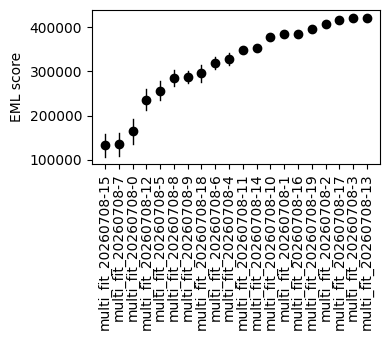

In [18]:
import numpy as np

# change the following line as needed
model_names = ['multi_fit_20260708-{}'.format(i) for i in range(20)]

eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(project_dir, model_names)
best_model = model_names[np.argmax(eml_scores)]
print(f"Best model: {best_model}")

kpms.plot_eml_scores(eml_scores, eml_std_errs, model_names)

## Focused Confusion Matrix Review

Compare the best model against few next best models

Reference model: multi_fit_20260708-13


<Figure size 600x500 with 0 Axes>

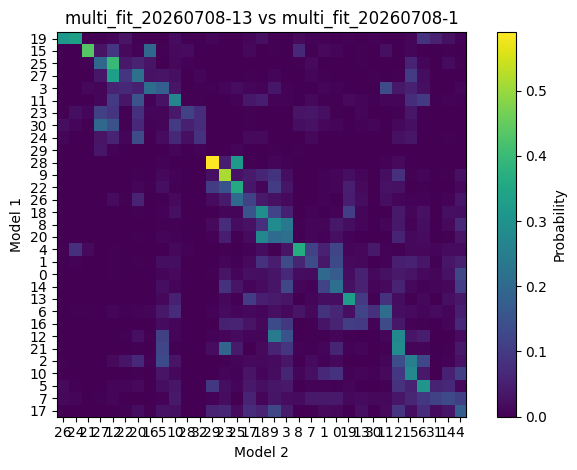

<Figure size 600x500 with 0 Axes>

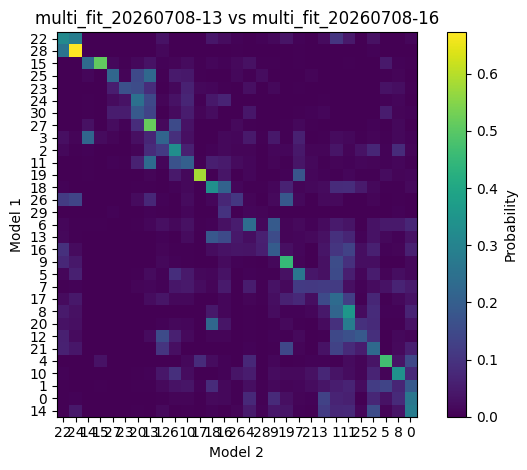

<Figure size 600x500 with 0 Axes>

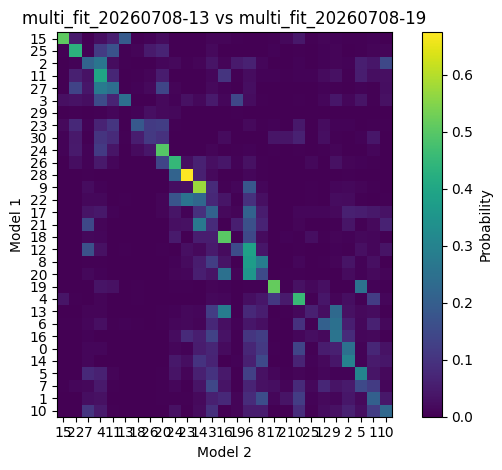

<Figure size 600x500 with 0 Axes>

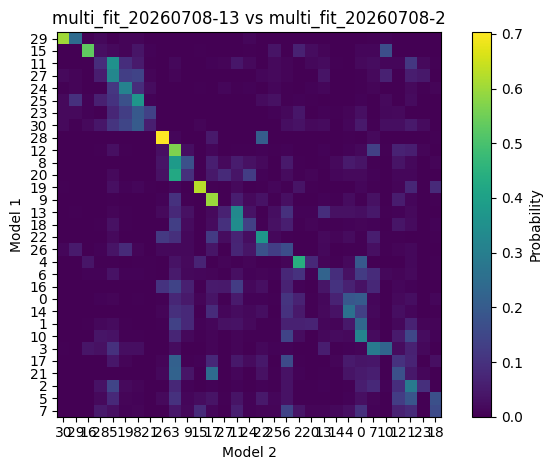

<Figure size 600x500 with 0 Axes>

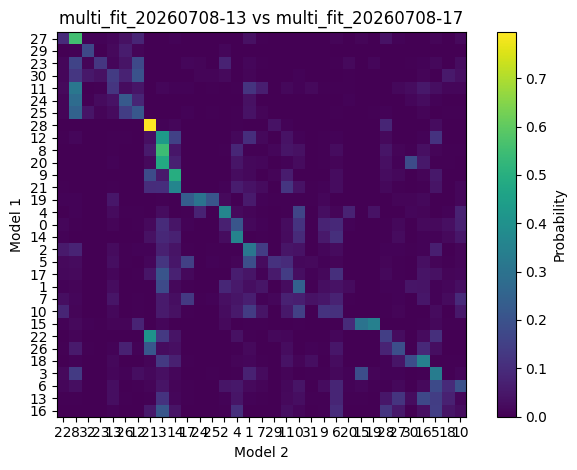

<Figure size 600x500 with 0 Axes>

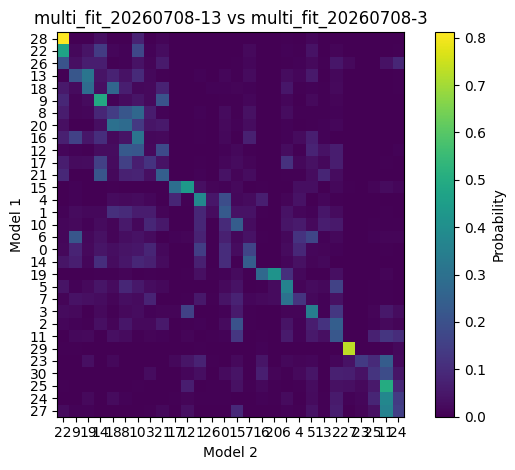

In [19]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt

prefix = "multi_fit_20260708"
num_models = 20
models = [1, 16, 19, 2, 17, 3]

ref = f"{prefix}-13"
print(f"Reference model: {ref}")
results_ref = kpms.load_results(str(project_dir), ref)

for i in models:
    other = f"{prefix}-{i}"
    results_other = kpms.load_results(str(project_dir), other)

    plt.figure(figsize=(6, 5))
    kpms.plot_confusion_matrix(results_ref, results_other)
    plt.title(f"{ref} vs {other}")
    plt.tight_layout()
    plt.show()